<a href="https://colab.research.google.com/github/aodm26/gpt-oss/blob/main/GPT_OSS_Reasoning_improved_proto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reasoning-Based Sentiment Analysis with GPT-OSS-20B

**Dataset:** 4,838 financial headlines · Labels: `0`=Positive · `1`=Negative · `2`=Neutral

## Speed strategy for T4 (14.5 GB VRAM)

Batching causes OOM on T4 with this 20B MoE model — the KV cache alone for 8 sequences
exhausts available memory. Instead we maximise speed **within a single sequence**:

| Optimisation | Effect |
|---|---|
| `load_in_4bit=True` | Cuts model weight memory ~4×; frees VRAM for KV cache |
| `reasoning_effort='low'` | Short think chain — was 167 s/headline on `high` |
| `max_new_tokens=128` | Label + 2-sentence reason fits easily |
| `do_sample=False` | Greedy decode — no sampling overhead |
| `use_cache=True` (default) | KV cache reuse within each generation |
| Prompt asks for label on last line | Zero-ambiguity parsing |
| Batch size = 1 | Avoids KV-cache OOM on T4 |

**Expected time:** ~10–20 s/headline → **15–25 min total** for 80 headlines.


## 1. Install Dependencies

In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch>=2.8.0" "triton>=3.4.0" {_numpy} {_pil} torchvision bitsandbytes "transformers==4.56.2" \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth" \
        git+https://github.com/triton-lang/triton.git@0add68262ab0a2e33b84524346cb27cbb2787356#subdirectory=python/triton_kernels
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps transformers==4.56.2 tokenizers trl==0.22.2 unsloth unsloth_zoo

## 2. Load Model & Tokenizer

In [2]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = "unsloth/gpt-oss-20b-unsloth-bnb-4bit",  # 4-bit quant — fits T4
    dtype         = None,       # auto
    max_seq_length= 2048,       # reduced from 4096 — shrinks KV cache allocation
    load_in_4bit  = True,       # ← key fix: ~4× less VRAM for weights
    full_finetuning = False,
)
# Put model in inference mode — disables dropout, enables optimised kernels
FastLanguageModel.for_inference(model)
print("Model loaded in 4-bit. Ready for inference.")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Gpt_Oss patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gpt_oss won't work! Using float32.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.37G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Model loaded in 4-bit. Ready for inference.


## 3. Load Dataset & Random Sample 80 Headlines

In [3]:
import pandas as pd

# ── Load full dataset ──────────────────────────────────────────────────────────
df = pd.read_excel('/content/dataset.xlsx')
print(f'Full dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print('\nSentiment label distribution (raw):')
label_map_preview = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}
print(df['sentiment'].value_counts().sort_index().rename(label_map_preview))
print(df.head(3))


Full dataset shape: (4838, 2)
Columns: ['sentiment', 'text']

Sentiment label distribution (raw):
sentiment
Positive    1362
Negative     604
Neutral     2872
Name: count, dtype: int64
   sentiment                                               text
0          2  According to Gran, the company has no plans to...
1          2  Technopolis plans to develop in stages an area...
2          1  The international electronic industry company ...


In [4]:
# ── Configuration ────────────────────────────────────────────────────────────
HEADLINE_COL = 'text'
LABEL_COL    = 'sentiment'   # numeric: 0=Positive, 1=Negative, 2=Neutral
RANDOM_STATE = 42            # change for a different random draw
N_SAMPLES    = 80

# ── Numeric → text label mapping ──────────────────────────────────────────────
LABEL_MAP = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}

# ── Random sample ─────────────────────────────────────────────────────────────
sample_df = df.sample(n=N_SAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)
headlines_list  = sample_df[HEADLINE_COL].tolist()
expected_labels = sample_df[LABEL_COL].map(LABEL_MAP).tolist()

print(f'Randomly sampled {len(headlines_list)} headlines (random_state={RANDOM_STATE}).')
print(f'Expected label distribution:')
import collections
print(dict(collections.Counter(expected_labels)))
print('\nFirst 3 headlines:')
for i, h in enumerate(headlines_list[:3]):
    print(f'  {i+1}. [{expected_labels[i]}] {h[:90]}...')


Randomly sampled 80 headlines (random_state=42).
Expected label distribution:
{'Neutral': 49, 'Positive': 23, 'Negative': 8}

First 3 headlines:
  1. [Neutral] The Company serves approximately 3,000 customers in over 100 countries....
  2. [Neutral] On Dec. 1, Grimaldi acquired 1.5 million shares and a 50.1-percent stake in Finnlines....
  3. [Neutral] The extracted filtrates are very high in clarity while the dried filter cakes meet require...


## 4. Helper: Parse Final Label from Model Output

The model's final line typically reads `**Final sentiment label:** **Positive**`.
The parser uses a priority-ordered regex search so it is robust to minor formatting changes.

In [5]:
import re

VALID_LABELS = {'Positive', 'Negative', 'Neutral'}

def parse_label(text: str) -> str:
    """
    Extract the final sentiment label from model output.
    Tries several patterns in order of specificity.
    Returns 'Unknown' if no valid label is found.
    """
    text_clean = text.replace('**', '').replace('*', '')

    # Pattern 1: explicit label line (e.g. "Final sentiment label: Positive")
    m = re.search(
        r'[Ff]inal\s+(?:sentiment\s+)?label[:\s]+([A-Za-z]+)',
        text_clean
    )
    if m and m.group(1).capitalize() in VALID_LABELS:
        return m.group(1).capitalize()

    # Pattern 2: last occurrence of a valid label word in the text
    found = re.findall(r'\b(Positive|Negative|Neutral)\b', text, re.IGNORECASE)
    if found:
        return found[-1].capitalize()

    return 'Unknown'

# Quick sanity check
assert parse_label("**Final sentiment label:** **Positive**") == "Positive"
assert parse_label("Final Sentiment Label: Negative") == "Negative"
assert parse_label("the overall tone is neutral.") == "Neutral"
print("parse_label() sanity checks passed.")

parse_label() sanity checks passed.


## 5. Run Inference on 80 Headlines

**One headline at a time** — batching causes KV-cache OOM on the T4 GPU with this model.  
All other speed levers are applied: 4-bit weights, `reasoning_effort='low'`, `max_new_tokens=128`, greedy decode.

Progress is printed after every headline so you can monitor the ETA live.


In [6]:
import torch, time, textwrap

SYSTEM_PROMPT = textwrap.dedent("""
    You are a financial news sentiment classifier.
    In 1-2 sentences explain your reasoning, then on the very last line
    write exactly one word — the sentiment label.
    The only valid labels are: Positive  Negative  Neutral
""").strip()

MAX_NEW_TOK = 128   # 1-2 sentence reason + label word fits in 128 tokens
results     = []
start       = time.time()
n           = len(headlines_list)

for i, (headline, exp) in enumerate(zip(headlines_list, expected_labels)):

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Headline: {headline}"},
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        return_tensors        = "pt",
        return_dict           = True,
        reasoning_effort      = "low",   # short internal trace
    ).to("cuda")

    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens = MAX_NEW_TOK,
            do_sample      = False,                    # greedy — fastest
            pad_token_id   = tokenizer.eos_token_id,
            use_cache      = True,                     # KV cache reuse within generation
        )

    input_len = inputs["input_ids"].shape[1]
    response  = tokenizer.decode(out_ids[0][input_len:], skip_special_tokens=True).strip()
    pred      = parse_label(response)
    correct   = (pred == exp)

    results.append({
        "index":     i + 1,
        "headline":  headline,
        "expected":  exp,
        "predicted": pred,
        "correct":   correct,
        "reasoning": response,
    })

    elapsed = time.time() - start
    rate    = elapsed / (i + 1)
    eta     = rate * (n - i - 1)
    tick    = "✓" if correct else "✗"
    print(f"[{i+1:3d}/80] {tick} exp={exp:<9s} pred={pred:<9s} "
          f"| {rate:.1f}s/item | ETA≈{eta/60:.1f}min")

total_min = (time.time() - start) / 60
print(f"\nDone! Total time: {total_min:.1f} min")


[  1/80] ✓ exp=Neutral   pred=Neutral   | 56.0s/item | ETA≈73.8min
[  2/80] ✓ exp=Neutral   pred=Neutral   | 42.3s/item | ETA≈54.9min
[  3/80] ✓ exp=Neutral   pred=Neutral   | 37.4s/item | ETA≈48.0min
[  4/80] ✓ exp=Neutral   pred=Neutral   | 34.1s/item | ETA≈43.2min
[  5/80] ✗ exp=Positive  pred=Neutral   | 35.1s/item | ETA≈43.9min
[  6/80] ✗ exp=Positive  pred=Neutral   | 36.0s/item | ETA≈44.3min
[  7/80] ✓ exp=Neutral   pred=Neutral   | 34.5s/item | ETA≈41.9min
[  8/80] ✗ exp=Neutral   pred=Positive  | 32.8s/item | ETA≈39.3min
[  9/80] ✓ exp=Neutral   pred=Neutral   | 32.0s/item | ETA≈37.8min
[ 10/80] ✓ exp=Neutral   pred=Neutral   | 30.9s/item | ETA≈36.1min
[ 11/80] ✓ exp=Neutral   pred=Neutral   | 30.6s/item | ETA≈35.2min
[ 12/80] ✓ exp=Neutral   pred=Neutral   | 30.6s/item | ETA≈34.6min
[ 13/80] ✓ exp=Neutral   pred=Neutral   | 30.3s/item | ETA≈33.8min
[ 14/80] ✗ exp=Positive  pred=Neutral   | 29.9s/item | ETA≈32.9min
[ 15/80] ✓ exp=Neutral   pred=Neutral   | 30.6s/item | ETA≈33.

## 6. Accuracy & Detailed Results

HEADLINE | EXPECTED   | PREDICTED  | MATCH
    1 | Neutral    | Neutral    | ✓
    2 | Neutral    | Neutral    | ✓
    3 | Neutral    | Neutral    | ✓
    4 | Neutral    | Neutral    | ✓
    5 | Positive   | Neutral    | ✗
    6 | Positive   | Neutral    | ✗
    7 | Neutral    | Neutral    | ✓
    8 | Neutral    | Positive   | ✗
    9 | Neutral    | Neutral    | ✓
   10 | Neutral    | Neutral    | ✓
   11 | Neutral    | Neutral    | ✓
   12 | Neutral    | Neutral    | ✓
   13 | Neutral    | Neutral    | ✓
   14 | Positive   | Neutral    | ✗
   15 | Neutral    | Neutral    | ✓
   16 | Positive   | Neutral    | ✗
   17 | Neutral    | Neutral    | ✓
   18 | Positive   | Positive   | ✓
   19 | Positive   | Positive   | ✓
   20 | Negative   | Negative   | ✓
   21 | Neutral    | Neutral    | ✓
   22 | Neutral    | Neutral    | ✓
   23 | Positive   | Positive   | ✓
   24 | Neutral    | Neutral    | ✓
   25 | Neutral    | Neutral    | ✓
   26 | Neutral    | Neutral    | ✓
   27 | Neutral    | 

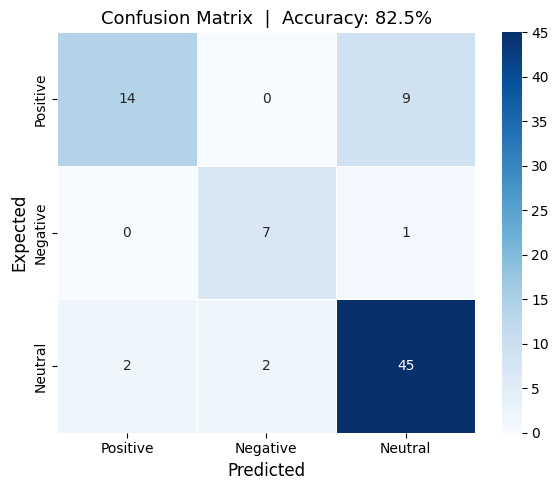

Confusion matrix saved to confusion_matrix.png


In [7]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(results)

# ── Summary table ──────────────────────────────────────────────────────────────
print("=" * 70)
print(f"{'HEADLINE':5s} | {'EXPECTED':10s} | {'PREDICTED':10s} | MATCH")
print("=" * 70)
for _, row in results_df.iterrows():
    match = "✓" if row['correct'] else "✗" if row['correct'] is False else "-"
    print(f"{int(row['index']):5d} | {str(row['expected']):10s} | {str(row['predicted']):10s} | {match}")

# ── Accuracy metrics (only if ground-truth labels available) ───────────────────
if expected_labels:
    y_true = results_df['expected'].tolist()
    y_pred = results_df['predicted'].tolist()

    acc = accuracy_score(y_true, y_pred)
    n_correct  = results_df['correct'].sum()
    n_unknown  = (results_df['predicted'] == 'Unknown').sum()

    print("\n" + "=" * 70)
    print(f"Overall Accuracy : {acc:.1%}  ({n_correct}/{len(results_df)} correct)")
    print(f"Unparsed labels  : {n_unknown}")
    print("=" * 70)
    print("\nPer-class Report:")
    print(classification_report(y_true, y_pred,
                                  labels=['Positive','Negative','Neutral'],
                                  zero_division=0))

    # ── Confusion matrix ──────────────────────────────────────────────────────
    labels = ['Positive', 'Negative', 'Neutral']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        ax=ax, linewidths=0.5
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Expected',  fontsize=12)
    ax.set_title(f'Confusion Matrix  |  Accuracy: {acc:.1%}', fontsize=13)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()
    print("Confusion matrix saved to confusion_matrix.png")
else:
    print("\nNo ground-truth labels — skipping accuracy metrics.")

## 7. Inspect Misclassified Headlines

In [8]:
if expected_labels:
    wrong_df = results_df[results_df['correct'] == False][['index', 'headline', 'expected', 'predicted']]
    print(f"Misclassified headlines: {len(wrong_df)} / {len(results_df)}")
    print()
    for _, row in wrong_df.iterrows():
        print(f"#{int(row['index'])} Expected={row['expected']} | Predicted={row['predicted']}")
        print(f"  {row['headline'][:120]}")
        print()
else:
    print("No ground-truth labels — skipping misclassification review.")

Misclassified headlines: 14 / 80

#5 Expected=Positive | Predicted=Neutral
  In recent months, Capman has taken significant steps to simplify its operations, CEO Lennart Simonsen said.

#6 Expected=Positive | Predicted=Neutral
  Shareholders of Rakvere Lihakombinaat decided in favor of the buyout of minority shares in mid-July.

#8 Expected=Neutral | Predicted=Positive
  wins 98% acceptance 23 December 2009 - Finnish industrial machinery company Metso Oyj (HEL: MEO 1V) said today it will c

#14 Expected=Positive | Predicted=Neutral
  Global Banking News - 28 September 2010 Tieto Corporation and Pohjola Bank (PINK: POJLF) are to cooperate on SWIFT servi

#16 Expected=Positive | Predicted=Neutral
  After the transaction, Alma Media raised its stake in Talentum to 30.65% of the shares and some 31.12% of voting rights.

#28 Expected=Positive | Predicted=Neutral
  The Vaisala Group is a successful international technology company that develops, manufactures and markets electronic me

#33 Ex

## 8. Save Results to CSV

In [9]:
out_path = '/content/sentiment_results.csv'
results_df[['index', 'headline', 'expected', 'predicted', 'correct']].to_csv(out_path, index=False)
print(f"Results saved → {out_path}")

# Also show a quick label distribution comparison
if expected_labels:
    print("\nLabel distribution comparison:")
    comparison = pd.DataFrame({
        'Expected' : pd.Series(results_df['expected'].value_counts()),
        'Predicted': pd.Series(results_df['predicted'].value_counts()),
    }).fillna(0).astype(int)
    print(comparison.to_string())

Results saved → /content/sentiment_results.csv

Label distribution comparison:
          Expected  Predicted
Neutral         49         55
Positive        23         16
Negative         8          9
